In [1]:
import os
import json
import shutil
import pickle
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization, Bidirectional, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from keras.utils import plot_model


2025-02-09 22:34:28.460729: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-09 22:34:29.383032: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# check if the gpu support available
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2025-02-09 22:34:33.016102: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-02-09 22:34:33.150351: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-02-09 22:34:33.150552: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [3]:
data_directory = '../all_outputs/output_holistic_pickle_ssl_full/'

In [5]:
filenames = set(os.listdir(data_directory))
print(f"Number of files: {len(filenames)}")

Number of files: 3150


In [92]:
class_names = {
    'w012': 'Tuesday',
    'w006': 'Mother',
    'w005': 'Talk',
    'w010': 'When',
    'w002': 'How',
    'w011': 'My',
    'w003': 'Child',
    'w013': 'I',
    'w008': 'What',
    'w001': 'You',
    'w014': 'Class',
    'w004': 'Sinhala',
    'w000': 'No_class',
    'w009': 'Exam',
    'w015': 'Go'
}

In [6]:
# Shape of dataset (videos, frames, landmarks_fflattened)
# Number of videos = number of files in data_directory
# We take X frames from each video
# 

all_data = []

In [7]:
# Define indices for points of interest
pose_indices = [0, 11, 12, 13, 14, 15, 16, 23, 24]
hand_indices = [0, 1, 3, 4, 6, 8, 10, 12, 14, 16, 18, 20]

In [8]:

def load_landmarks(filenames, num_frames):
    
    
    # Prepare storage for data and labels
    video_data = []
    labels = []
    
    for file in filenames:
        # Get the last part of file name
        file_name = os.path.basename(file)
        # if file_name contains 'still' then continue the loop
        if 'still' in file_name:
            continue
        file_name = file_name.split('-')[2]
        gloss = file_name[0:4]  # label for current video
        # print(gloss)

        with open(os.path.join(data_directory, file), 'rb') as f:
                landmarks = pickle.load(f)
                    
                # Prepare frame storage for each video with fixed number of frames
                frames = []

                # Get frame sampling step (skip frames if necessary)
                total_frames = len(landmarks)
                step = max(1, total_frames // num_frames)
                    
                # Process frames
                for i in range(num_frames):
                    frame_index = i * step if total_frames >= num_frames else i
                    
                    if frame_index < total_frames:
                        frame = landmarks[frame_index]
                    else:
                        frame = None
                        
                    # Extract and flatten required points
                    pose_points = frame['pose_landmarks'] if frame and frame['pose_landmarks'] else [None] * 33
                    left_hand_points = frame['left_hand_landmarks'] if frame and frame['left_hand_landmarks'] else [None] * 21
                    right_hand_points = frame['right_hand_landmarks'] if frame and frame['right_hand_landmarks'] else [None] * 21
                        
                    # Collect only specified indices and flatten them
                    extracted_points = []

                    # Collect pose points first
                    for idx in pose_indices:
                        point = pose_points[idx] if pose_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])
                        
                    # print(left_hand_points)
                    for idx in hand_indices:
                        point = left_hand_points[idx] if left_hand_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])

                    # Collect right hand points
                    for idx in hand_indices:
                        point = right_hand_points[idx] if right_hand_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])
                        
                    frames.append(extracted_points)
                    
                # Add the processed video frames to the main array
                video_data.append(frames)
                labels.append(gloss)
                

    # Convert to numpy arrays
    video_data = np.array(video_data)
    labels = np.array(labels)
    
    return video_data, labels

# Example usage
num_frames = 30  # Desired fixed number of frames per video

video_data, labels = load_landmarks(filenames, num_frames)

# `video_data` has shape (number of videos, num_frames, number of points*2) where points*2 is the flattened landmark count
# `labels` contains the labels for each video


In [9]:
NUM_CLASSES = len(set(labels))
NUM_CLASSES

64

In [10]:
# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
labels_one_hot = to_categorical(labels_encoded, num_classes=NUM_CLASSES)

# Split dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(video_data, labels_one_hot, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.6, random_state=42)

# print train, val, test shapes
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(1872, 30, 66) (1872, 64)
(499, 30, 66) (499, 64)
(749, 30, 66) (749, 64)


In [98]:
# input_shape=(num_frames, len(pose_indices) * 2 + len(hand_indices) * 2 * 2)

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class PositionEmbedding(layers.Layer):
    def __init__(self, config):
        super(PositionEmbedding, self).__init__()
        self.position_embeddings = self.add_weight(
            name="position_embeddings",
            shape=(config.max_position_embeddings, config.hidden_size),
            initializer="random_normal",
            trainable=True,
        )
    
    def call(self, x):
        seq_length = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_length, delta=1)
        position_embeddings = tf.gather(self.position_embeddings, positions)
        return x + position_embeddings


class Transformer(Model):
    def __init__(self, config, n_classes=50):
        super(Transformer, self).__init__()
        self.l1 = layers.Dense(config.hidden_size, activation=None)
        self.embedding = PositionEmbedding(config)
        
        # Rename 'layers' to 'transformer_layers' to avoid conflict
        self.transformer_layers = [
            layers.MultiHeadAttention(num_heads=config.num_attention_heads, key_dim=config.hidden_size // config.num_attention_heads)
            for _ in range(config.num_hidden_layers)
        ]
        
        # Instantiate LayerNormalization layers in __init__
        self.layer_norms = [
            layers.LayerNormalization(epsilon=1e-6)
            for _ in range(config.num_hidden_layers)
        ]
        
        self.l2 = layers.Dense(n_classes, activation=None)
        self.dropout = layers.Dropout(0.2)

    def call(self, x, training=False):
        x = self.l1(x)
        x = self.embedding(x)
        
        # Use 'transformer_layers' and 'layer_norms'
        for i, layer in enumerate(self.transformer_layers):
            x = layer(x, x)  # Self-attention
            x = self.layer_norms[i](x)  # Apply LayerNormalization
        
        x = tf.reduce_max(x, axis=1)  # Global max pooling
        x = self.dropout(x, training=training)
        x = self.l2(x)
        return x

In [37]:
# Configuration
class Config:
    input_size = 33 * 2  # 33 skeleton points, each with (x, y)
    hidden_size = 128
    num_hidden_layers = 8
    num_attention_heads = 8
    max_position_embeddings = 30  # Maximum number of frames
    num_classes = NUM_CLASSES  # Number of output classes

config = Config()

# Build the model
model = Transformer(config, n_classes=config.num_classes)

# Print the model summary
model.build(input_shape=(None, config.max_position_embeddings, config.input_size))
model.summary()

Model: "transformer_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_13 (Dense)            multiple                  8576      
                                                                 
 position_embedding_7 (Posi  multiple                  3840      
 tionEmbedding)                                                  
                                                                 
 multi_head_attention_48 (M  multiple                  66048     
 ultiHeadAttention)                                              
                                                                 
 multi_head_attention_49 (M  multiple                  66048     
 ultiHeadAttention)                                              
                                                                 
 multi_head_attention_50 (M  multiple                  66048     
 ultiHeadAttention)                                  

In [38]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=70, batch_size=32)

# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")




# Save label encoder and model if needed
# joblib.dump(label_encoder, 'label_encoder.pkl')
# model.save('lstm_landmark_model.h5')

Epoch 1/70
59/59 [==============================] - 18s 30ms/step - loss: 4.4390 - accuracy: 0.0224 - val_loss: 3.9374 - val_accuracy: 0.0361
Epoch 2/70
59/59 [==============================] - 1s 20ms/step - loss: 3.9208 - accuracy: 0.0331 - val_loss: 3.6920 - val_accuracy: 0.0481
Epoch 3/70
59/59 [==============================] - 1s 21ms/step - loss: 3.7986 - accuracy: 0.0363 - val_loss: 3.6406 - val_accuracy: 0.0401
Epoch 4/70
59/59 [==============================] - 1s 21ms/step - loss: 3.7439 - accuracy: 0.0481 - val_loss: 3.5413 - val_accuracy: 0.0421
Epoch 5/70
59/59 [==============================] - 1s 21ms/step - loss: 3.6241 - accuracy: 0.0673 - val_loss: 3.3515 - val_accuracy: 0.1022
Epoch 6/70
59/59 [==============================] - 1s 23ms/step - loss: 3.4958 - accuracy: 0.0839 - val_loss: 3.2166 - val_accuracy: 0.1303
Epoch 7/70
59/59 [==============================] - 1s 23ms/step - loss: 3.3875 - accuracy: 0.0988 - val_loss: 3.1122 - val_accuracy: 0.1503
Epoch 8/70
5

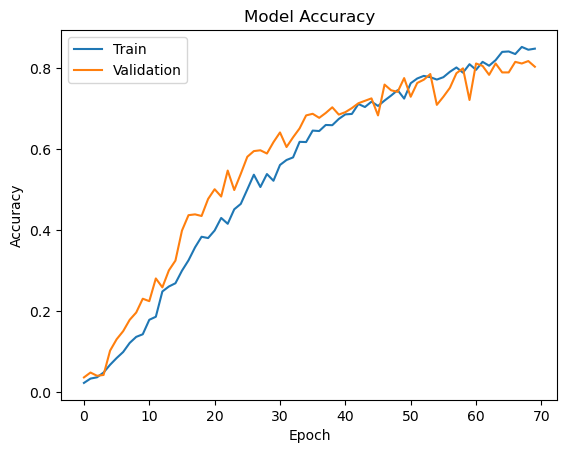

In [39]:

# Plot training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
save_plt = plt
plt.show()



24/24 [==============================] - 1s 5ms/step


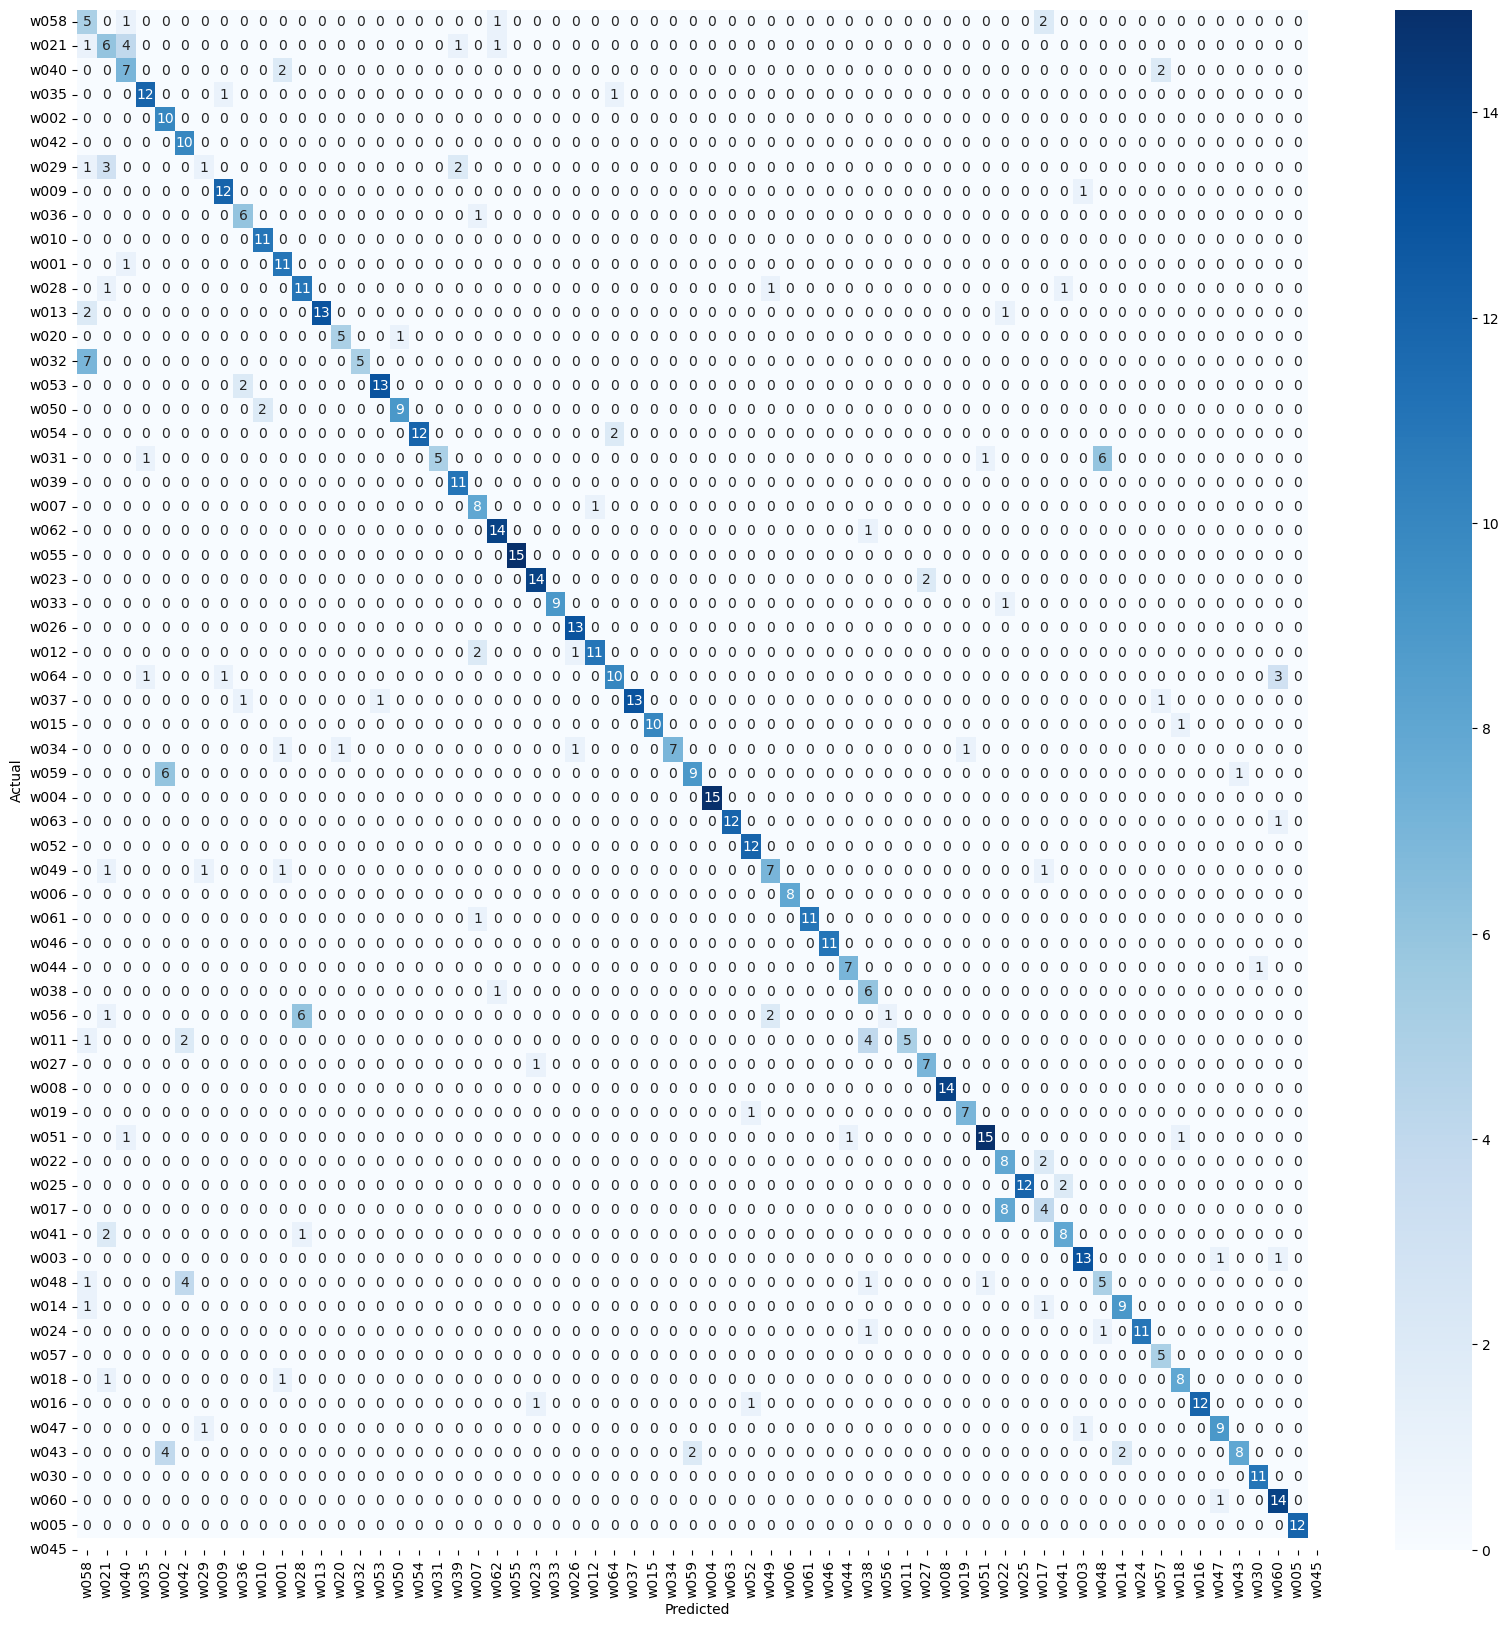

In [40]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test.argmax(axis=1), y_pred_classes)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(labels), yticklabels=set(labels))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

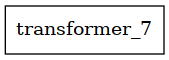

In [42]:
# plot model architecture
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

24/24 [==============================] - 0s 4ms/step


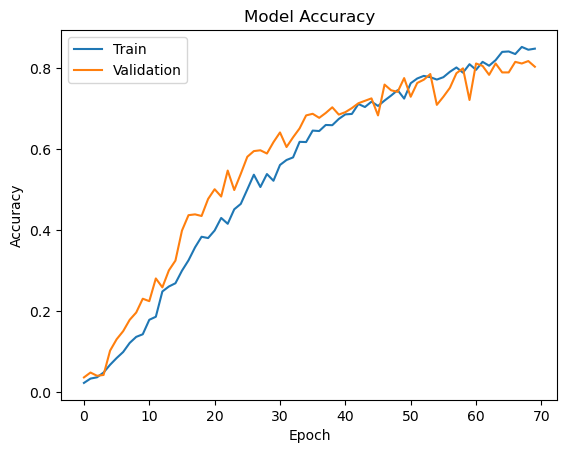

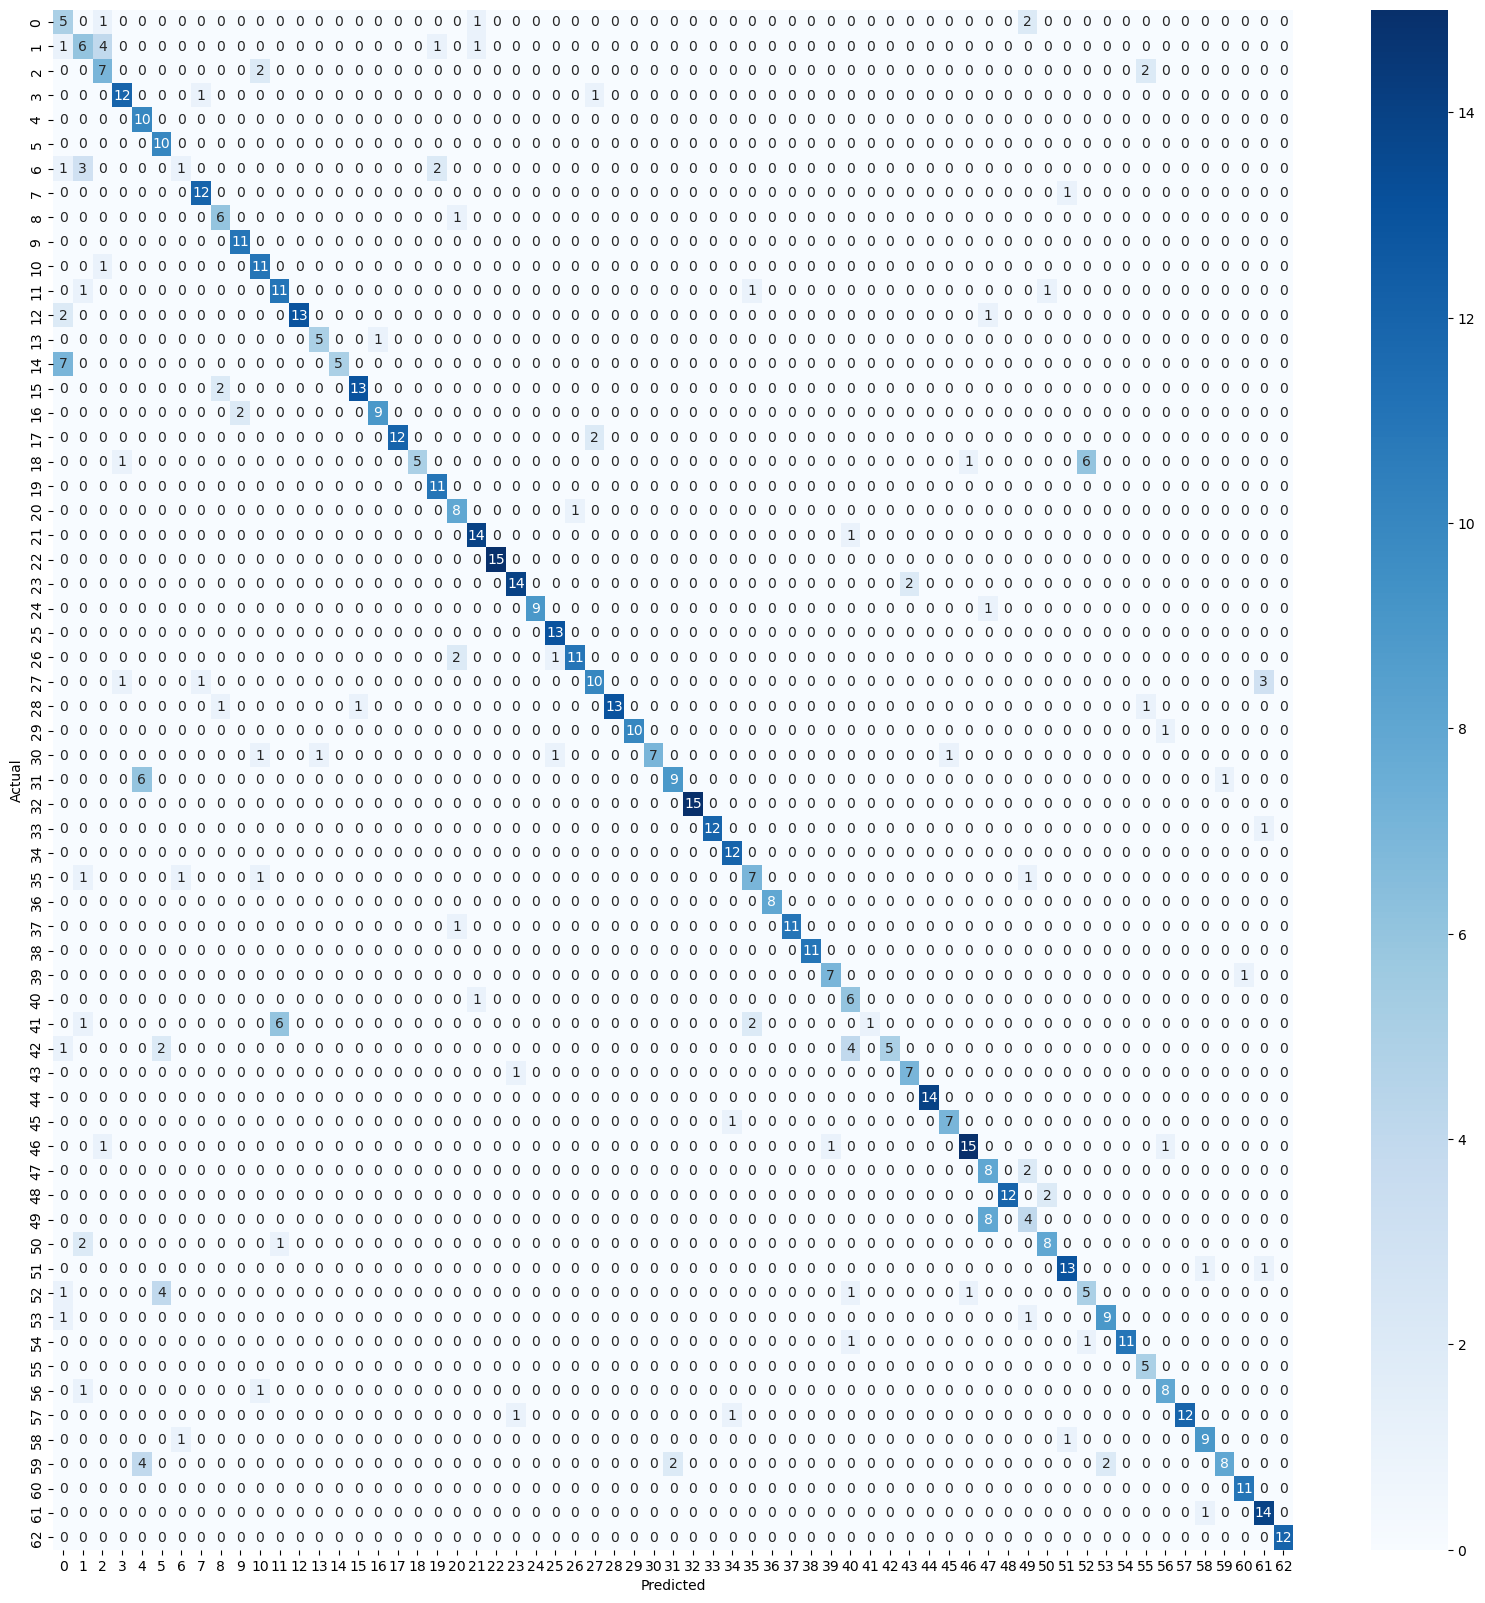

In [43]:
exp_number = 7
description = "64 class ssl data set trained on a transfomer network. model is taken from INCLUDE dataset's model - From model_6.ipynb"
result_dir = '../Results/exp_'

# create folder to store results and store results if folder is already there, show error
if not os.path.exists(result_dir + str(exp_number)):
    os.makedirs(result_dir + str(exp_number))

    with open(result_dir + str(exp_number) + '/description.txt', 'w') as f:
        f.write(description)

    # also save plots
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.savefig(result_dir + str(exp_number) + '/accuracy.png')

    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    cm = confusion_matrix(y_test.argmax(axis=1), y_pred_classes)
    plt.figure(figsize=(20, 20))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(result_dir + str(exp_number) + '/confusion_matrix.png')


else:
    print("Folder already exists")
